In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 设定已知参数（基于书中的 2007 年数据）
annual_mean_return = 0.1123      # SPY 年化平均收益率 (m_total)
annual_std_dev = 0.1691         # SPY 年化标准差 (s)
risk_free_rate = 0.04           # 无风险利率 (r)

# 2. 计算超额收益率 (m)
# m = 总收益 - 无风险利率
mean_excess_return = annual_mean_return - risk_free_rate

# 3. 计算夏普比率 (Sharpe Ratio)
sharpe_ratio = mean_excess_return / annual_std_dev

# 4. 根据凯利公式计算最优杠杆 (f*)
# f* = m / s^2
kelly_f = mean_excess_return / (annual_std_dev**2)

# 5. 计算两种情况下的年化复合增长率 (g)
# 公式：g(f) = r + f*m - (f^2 * s^2) / 2

# 情况 A: 不加杠杆 (f = 1)
g_unlevered = risk_free_rate + 1.0 * mean_excess_return - (1.0**2 * annual_std_dev**2) / 2

# 情况 B: 使用最优凯利杠杆 (f = kelly_f)
g_kelly = risk_free_rate + kelly_f * mean_excess_return - (kelly_f**2 * annual_std_dev**2) / 2

# --- 输出结果 ---
print(f"--- SPY 投资组合分析 ---")
print(f"年化超额收益率 (m): {mean_excess_return:.4%}")
print(f"年化波动率 (s): {annual_std_dev:.4%}")
print(f"夏普比率 (Sharpe Ratio): {sharpe_ratio:.4f}")
print("-" * 30)
print(f"最优凯利杠杆 (f*): {kelly_f:.3f}")
print(f"意味着 10 万本金应持有 ${100000 * kelly_f:,.0f} 的 SPY 仓位")
print("-" * 30)
print(f"不加杠杆 (f=1) 的长期复合增长率: {g_unlevered:.2%}")
print(f"使用凯利杠杆 (f={kelly_f:.3f}) 的长期复合增长率: {g_kelly:.2%}")

--- SPY 投资组合分析 ---
年化超额收益率 (m): 7.2300%
年化波动率 (s): 16.9100%
夏普比率 (Sharpe Ratio): 0.4276
------------------------------
最优凯利杠杆 (f*): 2.528
意味着 10 万本金应持有 $252,843 的 SPY 仓位
------------------------------
不加杠杆 (f=1) 的长期复合增长率: 9.80%
使用凯利杠杆 (f=2.528) 的长期复合增长率: 13.14%


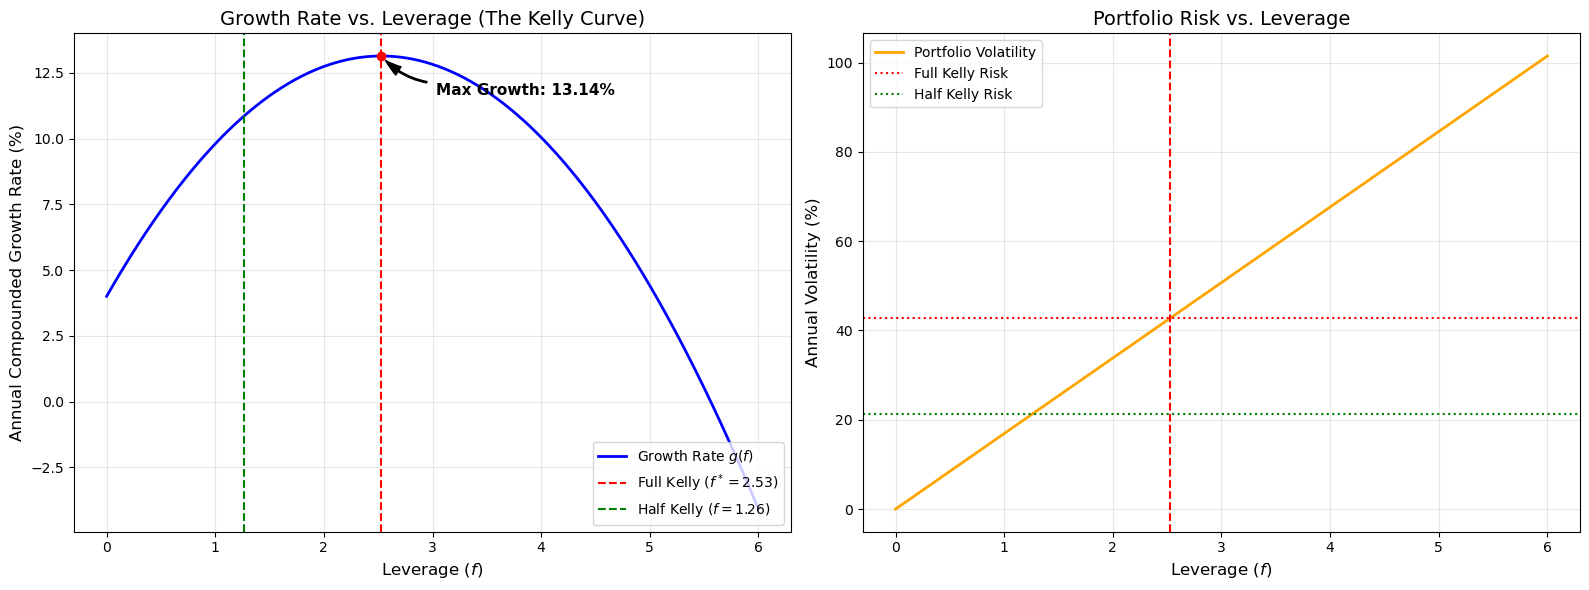

In [5]:
# --- 1. 设置参数 (Example 6.2) ---
m = annual_mean_return - risk_free_rate
s = annual_std_dev       
r = risk_free_rate
f_kelly = m / s**2  # 理论最优杠杆 (~2.528)

# --- 2. 定义函数 ---
def calc_growth_rate(f):
    # g(f) = r + f*m - (s^2 * f^2) / 2
    return r + f * m - (s**2 * f**2) / 2

def calc_volatility(f):
    # 账户整体波动率 = 杠杆 * 资产波动率
    return f * s

# 生成一系列杠杆倍数进行绘图 (从 0 到 6 倍杠杆)
f_range = np.linspace(0, 6, 500)
g_values = calc_growth_rate(f_range)
vol_values = calc_volatility(f_range)

# --- 3. 绘图 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 图 1: 复合增长率曲线 (The Kelly Curve)
ax1.plot(f_range, g_values * 100, label='Growth Rate $g(f)$', color='blue', lw=2)
ax1.axvline(f_kelly, color='red', linestyle='--', label=f'Full Kelly ($f^*={f_kelly:.2f}$)')
ax1.axvline(f_kelly/2, color='green', linestyle='--', label=f'Half Kelly ($f=1.26$)')
ax1.scatter([f_kelly], [calc_growth_rate(f_kelly)*100], color='red', zorder=5)

# 标注
ax1.set_title('Growth Rate vs. Leverage (The Kelly Curve)', fontsize=14)
ax1.set_xlabel('Leverage ($f$)', fontsize=12)
ax1.set_ylabel('Annual Compounded Growth Rate (%)', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.annotate(f'Max Growth: {calc_growth_rate(f_kelly)*100:.2f}%', 
             xy=(f_kelly, calc_growth_rate(f_kelly)*100), 
             # 向右偏移 0.5，向下偏移 1.5（你可以根据需要微调这个值）
             xytext=(f_kelly + 0.5, calc_growth_rate(f_kelly)*100 - 1.5),
             fontsize=11,
             fontweight='bold',
             arrowprops=dict(facecolor='black', 
                             shrink=0.1, 
                             width=1, 
                             headwidth=7, 
                             connectionstyle="arc3,rad=-0.2")) # 添加一点弧度让箭头更美观

# 图 2: 风险（波动率）随杠杆的变化
ax2.plot(f_range, vol_values * 100, color='orange', lw=2, label='Portfolio Volatility')
ax2.axvline(f_kelly, color='red', linestyle='--')
ax2.axhline(calc_volatility(f_kelly)*100, color='red', linestyle=':', label='Full Kelly Risk')
ax2.axhline(calc_volatility(f_kelly/2)*100, color='green', linestyle=':', label='Half Kelly Risk')

ax2.set_title('Portfolio Risk vs. Leverage', fontsize=14)
ax2.set_xlabel('Leverage ($f$)', fontsize=12)
ax2.set_ylabel('Annual Volatility (%)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

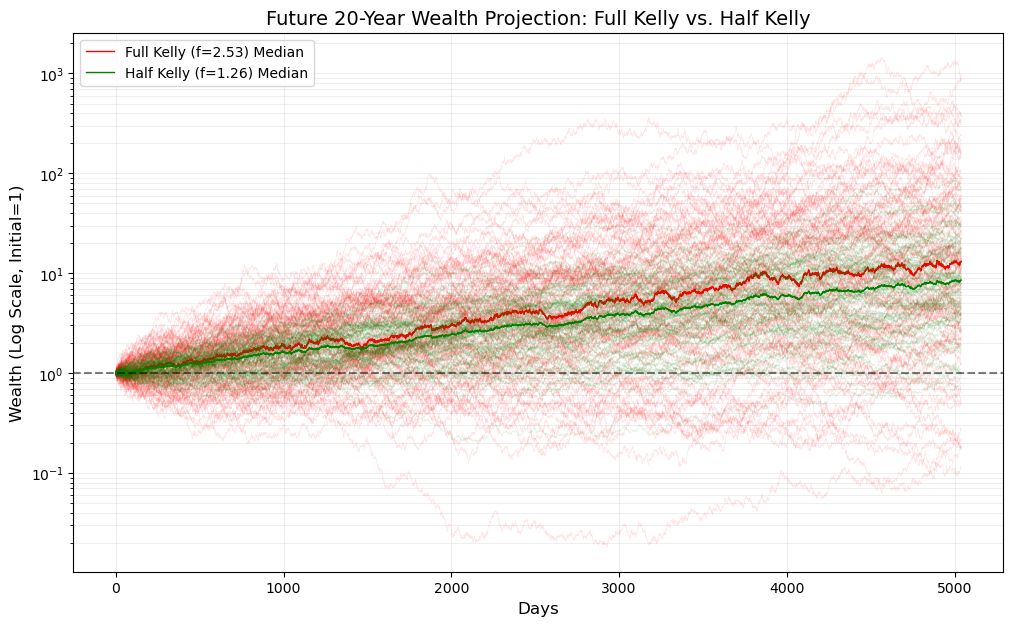

In [9]:
# --- 1. 参数设置 (基于推导后的符号规范) ---
f_full = f_kelly
f_half = f_kelly / 2      

n_years = 20      
dt = 1/252        # 每一时间步 (交易日)
n_steps = int(n_years / dt)
n_paths = 100     

# --- 2. 模拟随机路径 (使用 dB 代表标准噪音) ---
np.random.seed(42) 

# dB ~ N(0, dt)，代表标准布朗运动的增量
dB = np.random.normal(0, np.sqrt(dt), (n_steps, n_paths))

def simulate_wealth(f):
    # m_eff = r + f * (mu - r)
    # sigma_eff = f * sigma
    # 根据伊藤引理推导的对数增长率公式:
    # d(ln W) = (m_eff - 0.5 * sigma_eff^2) * dt + sigma_eff * dB
    
    m_eff = r + f * m
    sigma_eff = f * s
    
    # 计算每日的对数收益率增量
    # 这一步对应公式中的 d(ln W_t)
    daily_log_returns = (m_eff - 0.5 * sigma_eff**2) * dt + sigma_eff * dB
    
    # 财富 W_t = W_0 * exp( sum( d(ln W) ) )
    # 假设初始财富 W_0 = 1
    wealth_paths = np.exp(np.cumsum(daily_log_returns, axis=0))
    
    return wealth_paths

# 执行模拟
paths_full = simulate_wealth(f_full)
paths_half = simulate_wealth(f_half)



# --- 3. 绘图 ---
plt.figure(figsize=(12, 7))

# 绘制全凯利的路径 (淡红色细线)
plt.plot(paths_full, color='red', alpha=0.1, lw=0.5)
# 绘制全凯利的中位数路径 (深红色粗线)
plt.plot(np.median(paths_full, axis=1), color='red', lw=1, label=f'Full Kelly (f={f_full:.2f}) Median')

# 绘制半凯利的路径 (淡绿色细线)
plt.plot(paths_half, color='green', alpha=0.1, lw=0.5)
# 绘制半凯利的中位数路径 (深绿色粗线)
plt.plot(np.median(paths_half, axis=1), color='green', lw=1, label=f'Half Kelly (f={f_half:.2f}) Median')

# 格式化图表
plt.yscale('log') # 使用对数坐标轴，因为财富增长是指数级的
plt.title(f'Future 20-Year Wealth Projection: Full Kelly vs. Half Kelly', fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Wealth (Log Scale, Initial=1)', fontsize=12)
plt.axhline(1, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()